In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


In [ ]:
#Veri tiplerine bakalım
df.info()
df.dtypes

# Sayısal değişkenler hangileri?
# Kategorik değişken var mı? (Genellikle Gender)
# Hedef değişken var mı? (Bu veri seti genelde unsupervised kullanılır)
# Veri tipleri doğru mu?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   AnnualIncome   200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID        int64
Gender           object
Age               int64
AnnualIncome      int64
SpendingScore     int64
dtype: object

In [3]:
df.describe()
df.describe(include="object")

,Gender
count,200
unique,2
top,Female
freq,112


In [4]:
#Eksik veri kontrolü
df.isnull().sum()

CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

In [ ]:
#Yüzde olarak eksik veri kontrol
(df.isnull().mean() * 100).sort_values(ascending=False)

CustomerID       0.0
Gender           0.0
Age              0.0
AnnualIncome     0.0
SpendingScore    0.0
dtype: float64

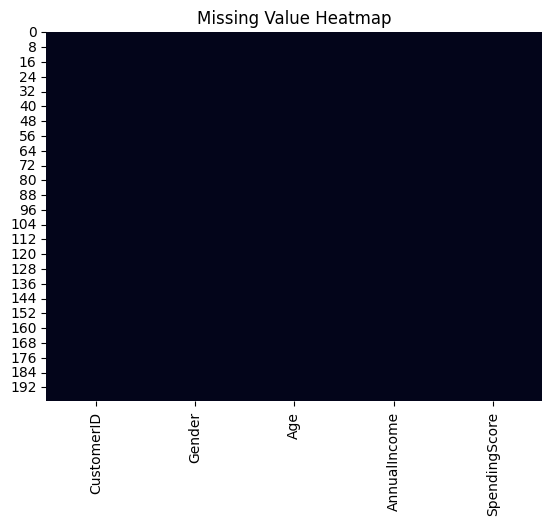

In [6]:
#Grafikle eksik veri kontrol
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

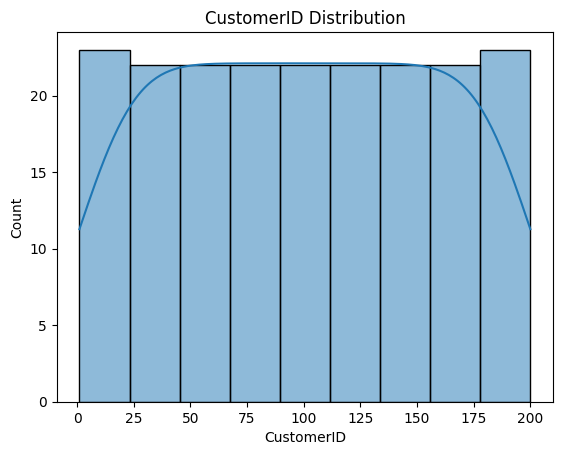

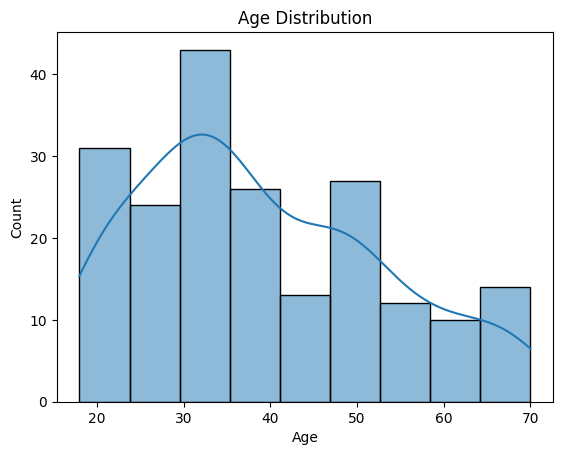

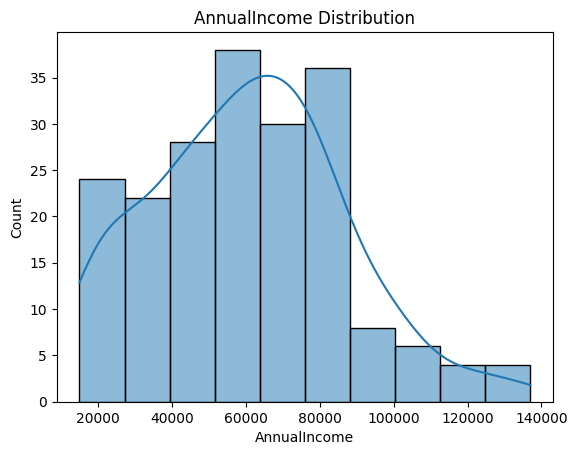

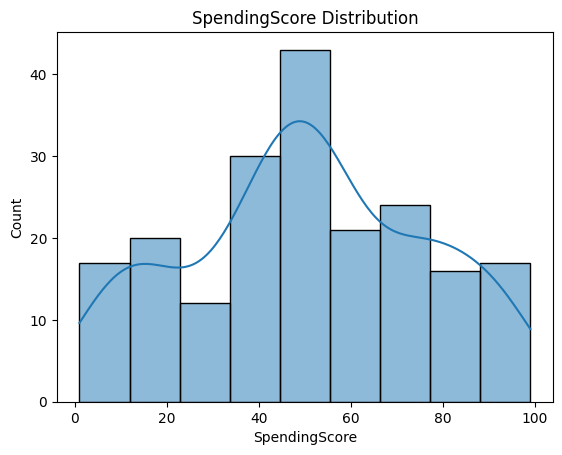

In [7]:
#Gürültü kontrolü için dağılımı inceleme
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

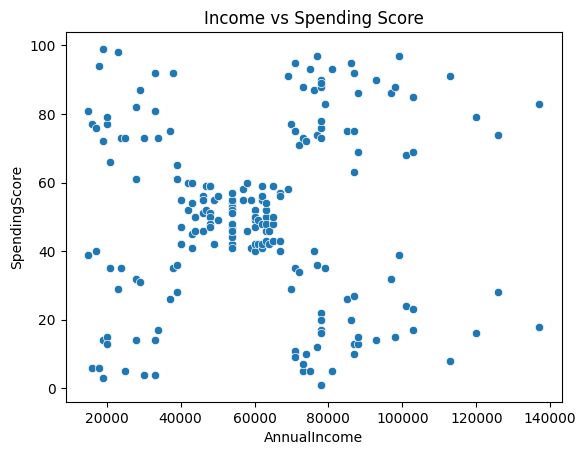

In [9]:
#Scatter analizi
sns.scatterplot(x="AnnualIncome", y="SpendingScore", data=df)
plt.title("Income vs Spending Score")
plt.show()

In [13]:
# Gürültü
# Noktalar aşırı dağınık mı?
# Belirli bir yapı var mı?
# Varyans aşırı mı?

# Varyans kontrolü:
df.var(numeric_only=True)

CustomerID       3.350000e+03
Age              1.951332e+02
AnnualIncome     6.898356e+08
SpendingScore    6.668543e+02
dtype: float64

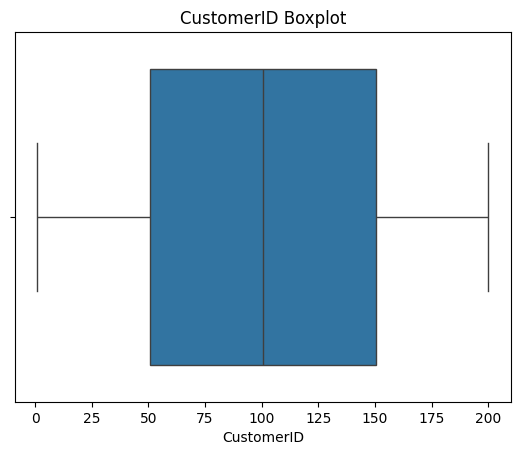

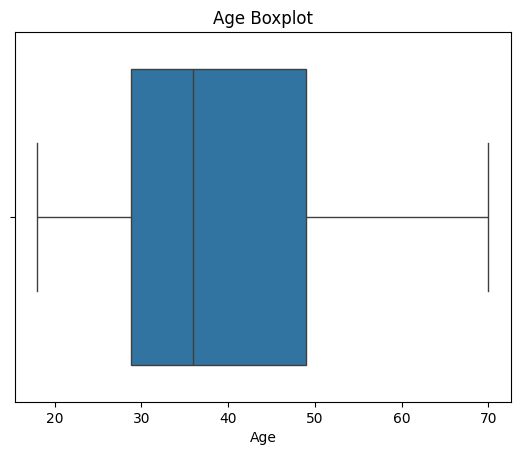

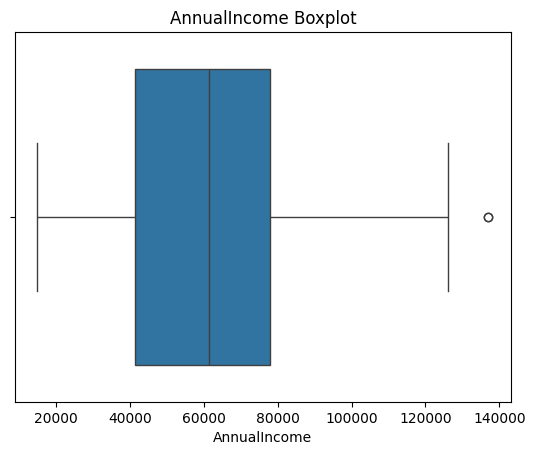

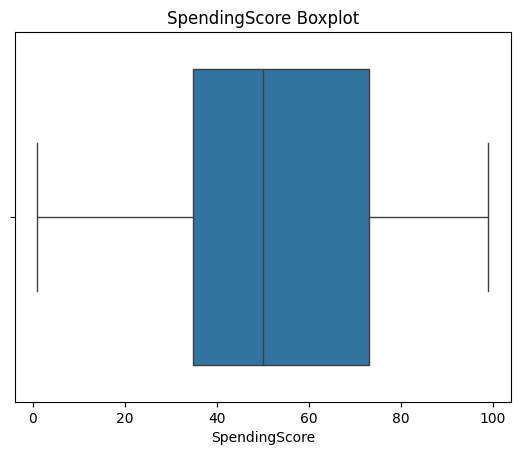

In [11]:
# Aykırı Değer Kontrolü
# Boxplot
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

In [12]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    return len(outliers)

for col in df.select_dtypes(include=np.number).columns:
    print(col, "Outlier count:", detect_outliers_iqr(df, col))

CustomerID Outlier count: 0
Age Outlier count: 0
AnnualIncome Outlier count: 2
SpendingScore Outlier count: 0


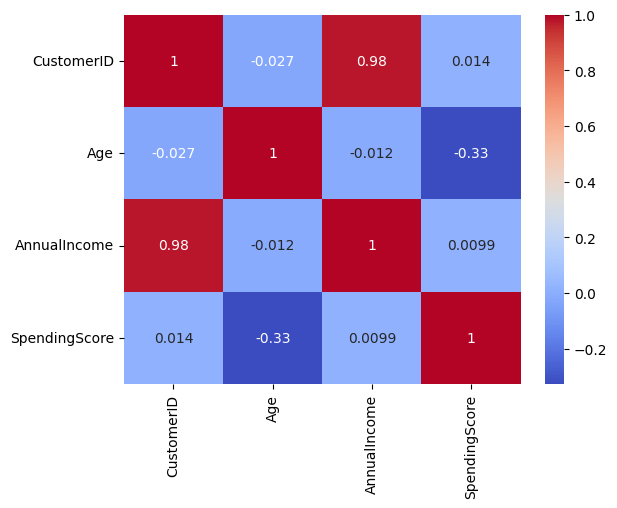

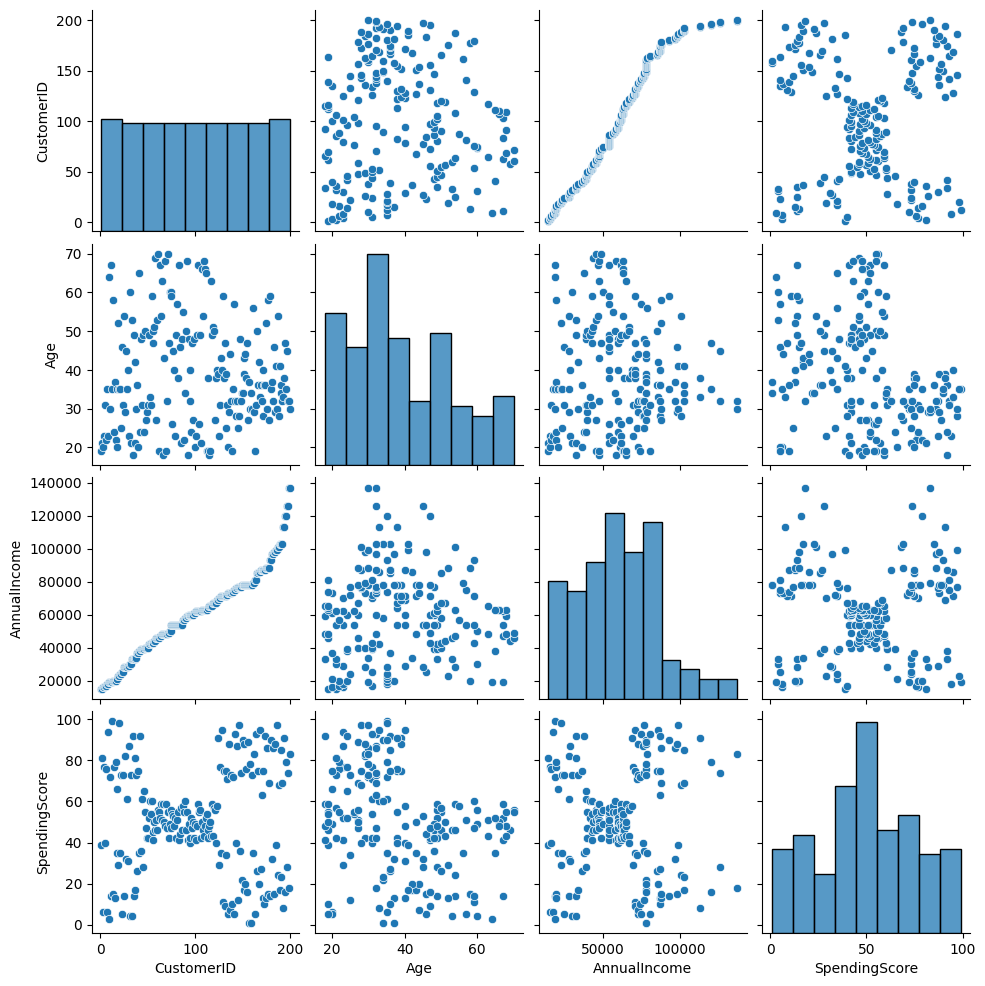

In [14]:
df.describe()

df.skew(numeric_only=True)

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

df.groupby("Gender").mean(numeric_only=True)

sns.pairplot(df)
plt.show()